In [108]:
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join
from PIL import Image

In [109]:
nnUNet_raw = "../knee_us_segmentation/data/nnUNet_raw"
nnUNet_results = "../knee_us_segmentation/data/nnUNet_results"

def get_dataset_name(nnUNet_raw, dataset_id):
    dataset_id = str(dataset_id).zfill(3)
    dataset_name = [dataset_name for dataset_name in os.listdir(nnUNet_raw) if dataset_name.startswith(f"Dataset{dataset_id}") and os.path.isdir(join(nnUNet_raw, dataset_name))]
    assert len(dataset_name) == 1, f"Found {len(dataset_name)} datasets with id {dataset_id}, expected 1"
    return dataset_name[0]

In [110]:
LEFT_LEG_FORMATS = {"l", "l1", "l2", "l3", "L", "L1", "L2", "L3"}
RIGHT_LEG_FORMATS = {"r", "r1", "r2", "r3", "R", "R1", "R2", "R3"}
INJ_LEG_FORMATS = {"inj", "injured"}
UNINJ_LEG_FORMATS = {"uninj", "noninj", "non-inj", "uninjured", "noninjured", "non-injured"}


def get_subject_id(img_id):
    img_id = os.path.basename(img_id).rsplit('.', 1)[0]
    if '___' in img_id:
        family, subject_part = img_id.rsplit('___', 1)
    else:
        family, subject_part = '', img_id

    tokens = subject_part.split('_')
    low_family = family.lower()
    low_part = subject_part.lower()

    if family == 'CaseControl_ACL':
        return f"CaseControl_ACL___{'_'.join(tokens[:2])}"
    if family == 'CaseControl_Control':
        return f"CaseControl_Control___{tokens[0]}"
    if family.startswith('Tufts_'):
        return f"Tufts___{tokens[0]}"
    if family.startswith('ACLMRI_') or 'mri' in low_part:
        return f"ACLMRI___{'_'.join(tokens[:2]).upper()}"
    if family.startswith('Nike_') or 'nike' in low_part:
        return f"NIKE___{'_'.join(tokens[:2]).upper()}"

    return tokens[0]


def separate_subjects(img_ids):
    return sorted({get_subject_id(img_id) for img_id in img_ids})


def get_case_prefix(img_id):
    img_id = os.path.basename(img_id).rsplit('.', 1)[0]
    parts = img_id.rsplit('_', 2)
    if len(parts) == 3 and parts[-2].isdigit() and parts[-1].isdigit():
        return parts[0]
    if len(parts) == 2 and parts[-1].isdigit():
        return parts[0]
    return img_id


def get_case_label(img_id):
    tokens = [token.lower() for token in get_case_prefix(img_id).split('_')]
    for token in tokens:
        if token in INJ_LEG_FORMATS:
            return 'inj'
    for token in tokens:
        if token in UNINJ_LEG_FORMATS:
            return 'non-inj'
    for token in tokens:
        if token in LEFT_LEG_FORMATS:
            return 'left'
    for token in tokens:
        if token in RIGHT_LEG_FORMATS:
            return 'right'
    return 'unknown'


def build_case_df(outcomes_df, subject_ids):
    case_rows = []
    for subject_id in subject_ids:
        subject_outcomes = outcomes_df[outcomes_df['subject_id'] == subject_id].copy()
        if len(subject_outcomes) == 0:
            continue

        for case_prefix, sample_rows in subject_outcomes.groupby('case_prefix', sort=True):
            if len(sample_rows) == 0:
                continue
            case_rows.append({
                'subject_id': subject_id,
                'case_label': sample_rows['case_label'].iloc[0],
                'case_prefix': case_prefix,
                'gt_thickness': sample_rows['gt_thickness'].mean(),
                'pred_thickness': sample_rows['pred_thickness'].mean(),
                'gt_echo_intensity': sample_rows['gt_echo_intensity'].mean(),
                'pred_echo_intensity': sample_rows['pred_echo_intensity'].mean(),
            })

    return pd.DataFrame(case_rows)

# Dataset Overview


In [111]:
from collections import Counter, defaultdict
import re

subject_dataset_ids = [72, 73, 70]
dataset_id2abbr = {72: 'D0', 73: 'D1', 70: 'D2'}
dataset_id2device = {
    72: 'GE LOGIQ P9 R3',
    73: 'GE LOGIQ e',
    70: 'Clarius HD3 L15',
}


def get_subject_group(subject_id):
    if subject_id.startswith('ACLMRI'):
        return 'ACL'
    if subject_id.startswith('CaseControl_ACL'):
        return 'ACL'
    return 'healthy'


def normalize_subject_analysis_image_id(image_id):
    return image_id.replace('s906 _V7', 's906_V7')


dataset_subjects = {}
dataset_rows = []
subject_to_datasets = defaultdict(set)
subject_to_images = defaultdict(list)

for dataset_id in subject_dataset_ids:
    dataset_name = get_dataset_name(nnUNet_raw, dataset_id)
    label_dir = join(nnUNet_raw, dataset_name, 'labelsTr')
    image_ids = sorted(normalize_subject_analysis_image_id(os.path.splitext(name)[0]) for name in os.listdir(label_dir) if name.endswith('.png'))
    subject_ids = sorted({get_subject_id(image_id) for image_id in image_ids})
    dataset_subjects[dataset_id] = subject_ids

    group_counts = Counter(get_subject_group(subject_id) for subject_id in subject_ids)
    dataset_rows.append({
        'dataset': dataset_name,
        'abbr': dataset_id2abbr[dataset_id],
        'device': dataset_id2device[dataset_id],
        'unique_subjects': len(subject_ids),
        'healthy_subjects': group_counts.get('healthy', 0),
        'acl_subjects': group_counts.get('ACL', 0),
        'images': len(image_ids),
    })

    for image_id in image_ids:
        subject_id = get_subject_id(image_id)
        subject_to_datasets[subject_id].add(dataset_id)
        subject_to_images[subject_id].append(image_id)

summary_df = pd.DataFrame(dataset_rows)
display(summary_df)

combined_subjects = sorted(subject_to_datasets.keys())
combined_group_counts = Counter(get_subject_group(subject_id) for subject_id in combined_subjects)

combined_df = pd.DataFrame([
    {
        'datasets': 'D0 + D1 + D2',
        'unique_subjects': len(combined_subjects),
        'healthy_subjects': combined_group_counts.get('healthy', 0),
        'acl_subjects': combined_group_counts.get('ACL', 0),
    }
])
display(combined_df)

multi_device_rows = []
for subject_id, dataset_ids in sorted(subject_to_datasets.items()):
    if len(dataset_ids) <= 1:
        continue
    multi_device_rows.append({
        'subject_id': subject_id,
        'datasets': ', '.join(dataset_id2abbr[dataset_id] for dataset_id in sorted(dataset_ids)),
        'devices': ', '.join(dataset_id2device[dataset_id] for dataset_id in sorted(dataset_ids)),
        'group': get_subject_group(subject_id),
    })

multi_device_df = pd.DataFrame(multi_device_rows)
print(f'Combined unique subjects across D0, D1, and D2: {len(combined_subjects)}')
print(f'Healthy subjects across D0, D1, and D2: {combined_group_counts.get("healthy", 0)}')
print(f'ACL subjects across D0, D1, and D2: {combined_group_counts.get("ACL", 0)}')
print(f'Subjects imaged with more than one device: {len(multi_device_df)}')

all_subject_rows = []
for subject_id in sorted(subject_to_datasets):
    dataset_ids = sorted(subject_to_datasets[subject_id])
    all_subject_rows.append({
        'subject_id': subject_id,
        'group': get_subject_group(subject_id),
        'datasets': ', '.join(dataset_id2abbr[dataset_id] for dataset_id in dataset_ids),
        'devices': ', '.join(dataset_id2device[dataset_id] for dataset_id in dataset_ids),
        'num_images': len(subject_to_images[subject_id]),
        'image_ids': subject_to_images[subject_id],
    })

all_subjects_df = pd.DataFrame(all_subject_rows)
all_subjects_csv_path = 'all_subjects_summary.csv'
all_subjects_df.to_csv(all_subjects_csv_path, index=False)
print(f'Saved all subjects summary to {all_subjects_csv_path}')

,dataset,abbr,device,unique_subjects,healthy_subjects,acl_subjects,images
0,Dataset072_GE_LQP9,D0,GE LOGIQ P9 R3,151,136,15,1787
1,Dataset073_GE_LE,D1,GE LOGIQ e,76,56,20,587
2,Dataset070_Clarius_L15,D2,Clarius HD3 L15,71,71,0,234


,datasets,unique_subjects,healthy_subjects,acl_subjects
0,D0 + D1 + D2,227,192,35


Combined unique subjects across D0, D1, and D2: 227
Healthy subjects across D0, D1, and D2: 192
ACL subjects across D0, D1, and D2: 35
Subjects imaged with more than one device: 71
Saved all subjects summary to all_subjects_summary.csv


# 3 splits results analysis

In [112]:
def visualize_outliers(df, model, metric, outliers_dict, nnUNet_raw, test_dataset, show=False):
    # Calculate Q1, Q3, and IQR
    Q1 = df[metric].quantile(0.25)
    Q3 = df[metric].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define outlier bounds (same as boxplot: 1.5 * IQR)
    lower_bound = 60 #Q1 - 1.5 * IQR
    upper_bound = 100
    
    # Filter for outliers
    outliers = df[(df['dice'] < lower_bound) | (df['dice'] > upper_bound)]
    outliers_dict[model] = outliers['image_id'].tolist()
    
    print(f"\n{model}:")
    print(f"  Total images: {len(df)}")
    print(f"  Outliers: {len(outliers)}")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
    
    num_outliers = len(outliers)
    
    if num_outliers > 0:
        print(f"  Outlier image IDs:")
        for idx, row in outliers.iterrows():
            print(f"    {row['image_id']}: dice={row['dice']:.2f}")
    
    if show:
        plt.figure(figsize=(15, 8))
        for i, outlier in enumerate(outliers_dict[model]):
            print(f"outlier: {outlier}")
            img_path = f"{nnUNet_raw}/{test_dataset}/imagesTr/{outlier}_0000.png"
            mask_path = f"{nnUNet_raw}/{test_dataset}/labelsTr/{outlier}.png"

            img = np.array(Image.open(img_path))
            mask = np.array(Image.open(mask_path))

            plt.subplot(1, len(outliers_dict[model]), i+1)
            plt.imshow(img, cmap='gray')
            plt.contour(mask, colors='yellow', levels=[0.5])
            plt.axis('off')
            if i == 2:
                break
        plt.show()

    return num_outliers

In [113]:
# These images have inaccurate annotations

ignore_ids = [
    "Nike_Brian___NIKE_S962_T4_R_CAR_3_1562",
    "Nike_Brian___NIKE_S975_T4_L_CAR_2_752",
    "Nike_XC_Jamil___NIKE_S129_T0_L_CAR_3_1119",
    "Nike_XC_Jamil___NIKE_S129_T0_L_CAR_1_895",
    "Nike_Brian___NIKE_S951_T4_R_CAR_3_1149",
    "20251103201014____frame_73_042",
    "20251103200953____frame_8_254",
    "20251103200953____frame_11_229",
    "20251103200953____frame_46_040",
    "20251103200953____frame_48_354",
    "20251103200953____frame_49_274",
    "20251103200953____frame_50_063",
    "20251103201014____frame_2_366",
    "20251103201014____frame_3_048",
    "20251103201014____frame_4_003",
    "20251103201014____frame_45_257",
    "20251103201014____frame_46_317",
    "20251103201014____frame_47_263",
    "20251103201014____frame_48_152",
    "20251103201014____frame_67_265",
    "20251103201014____frame_68_090",
    "20251103201014____frame_69_101",
    "20251103201014____frame_70_009",
    "20251103201014____frame_71_148",
    "20251103201014____frame_72_202",
    "20251103201014____frame_73_042",
    "20251103201014____frame_74_243",
    "20251103201014____frame_75_231",
    "20251103201014____frame_76_021",
    "20251103201043____frame_7_301",
    "20251103201043____frame_8_099",
    ""
]

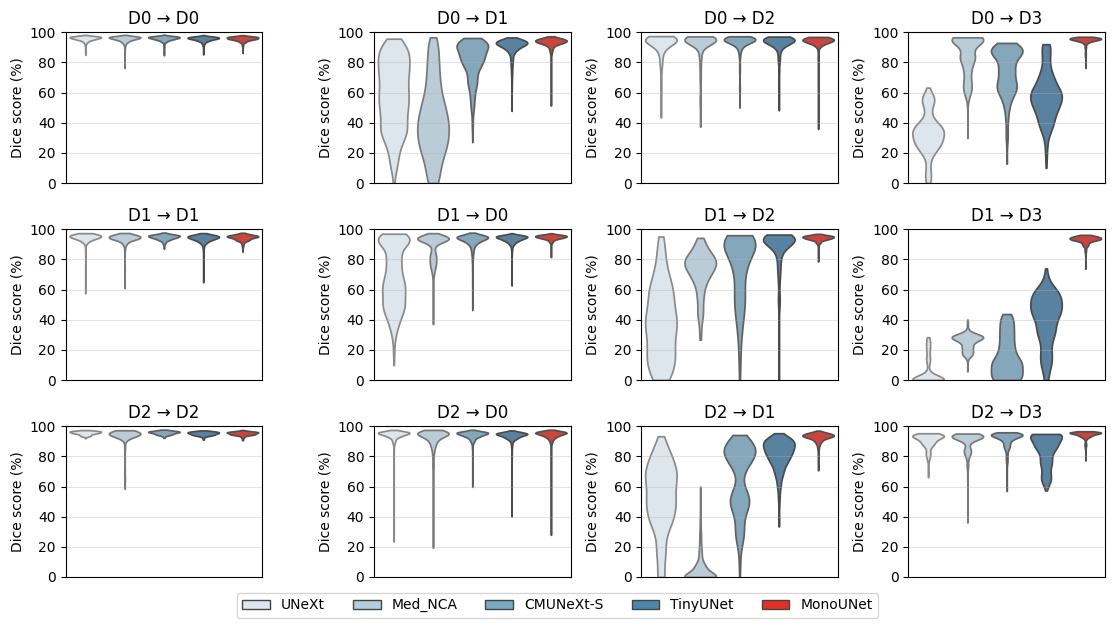

In [114]:
largest_component = True
data_augmentation = False

if data_augmentation:
    models = [
        "UNextDA",
        "Med_NCADA",
        "CMUNeXt-SDA",
        "TinyUNetDA",
    ]
else:
    models = [
        "UNext",
        "Med_NCA",
        "CMUNeXt-S",
        "TinyUNet"
    ]

models.append("MonoUNetE123V2GatedDA")

train_dataset_ids = [72, 73, 70]
all_test_dataset_ids = [72, 73, 70, 79]
dataset_id2abbr = {
    72: "D0",
    73: "D1",
    70: "D2",
    79: "D3",
}
folds = range(3)
metric = "dice"
# metric = "masd"
# metric = "hd95"

# Define colors for each model using seaborn palette
from matplotlib.patches import Patch
# colors = sns.color_palette(n_colors=len(models))
colors = sns.color_palette("Blues", n_colors=len(models), desat=0.7)[:-1] + [sns.color_palette("Reds", n_colors=2)[-1]] #sns.color_palette(n_colors=1)

fig = plt.figure(figsize=(11.25, 6))
gs = fig.add_gridspec(len(train_dataset_ids), 5, width_ratios=[1, -0.15, 1, 1, 1])
legend_handles = []
legend_labels = []

for i, train_dataset_id in enumerate(train_dataset_ids):
    test_dataset_ids = all_test_dataset_ids.copy()
    test_dataset_ids.remove(train_dataset_id)
    test_dataset_ids.insert(0, train_dataset_id)
    for j, test_dataset_id in enumerate(test_dataset_ids):
        train_dataset = get_dataset_name(nnUNet_raw, train_dataset_id)
        test_dataset = get_dataset_name(nnUNet_raw, test_dataset_id)

        ax = fig.add_subplot(gs[i, 0 if j == 0 else j + 1])
        plt.sca(ax)
        
        outliers_dict = {k: [] for k in models}
        
        for model_idx, model in enumerate(models):
            if metric != 'dice' and model == 'UNextDA':
                continue

            # Collect data across all folds for this model
            all_scores = []
            
            for fold in folds:
                # print(f"model: {model}")
                # print(f"train_dataset_id: {train_dataset_id}")
                # print(f"test_dataset_id: {test_dataset_id}")
                # print("fold: ", fold)
                
                if train_dataset == test_dataset:
                    image_wise_results_path = f"models/{model}/{train_dataset}/results_{test_dataset}.csv"
                else:
                    image_wise_results_path = f"models/{model}/{train_dataset}/fold_{fold}/test/results_{test_dataset}.csv"
                
                if not os.path.exists(image_wise_results_path):
                    print(f"Skipping {model} fold {fold} - missing {image_wise_results_path}")
                    continue
                # print(f"image_wise_results_path: {image_wise_results_path}")
                df = pd.read_csv(image_wise_results_path)
                # ignore the ignore ids
                df = df[~df['image_id'].isin(ignore_ids)]
                
                # Collect scores from this fold
                all_scores.append(df[metric].values)
                
                # if test_dataset == "Dataset070_Clarius_L15" and model == "MonoUNetE123V2GatedDA":
                #     print(test_dataset)
                #     visualize_outliers(df, model, outliers_dict, nnUNet_raw, test_dataset)

            if len(all_scores) == 0:
                continue

            all_scores = np.array(all_scores)
            all_scores = all_scores.mean(axis=0).tolist()
            
            # Create legend entry (only once per model, in first subplot)
            if i == 0 and j == 0:
                model_display_name = model.replace("MonoUNetE123V2GatedDA", "MonoUNet")
                model_display_name = model_display_name.replace("MonoUNetE123V2Gated", "MonoUNet")
                model_display_name = model_display_name.replace("UNextDA", "UNeXt")
                model_display_name = model_display_name.replace("Med_NCADA", "Med-NCA")
                model_display_name = model_display_name.replace("UNext", "UNeXt")
                model_display_name = model_display_name.replace("CMUNeXt-SDA", "CMUNeXt-S")
                model_display_name = model_display_name.replace("CMUNeXt-S", "CMUNeXt-S")
                model_display_name = model_display_name.replace("TinyUNetDA", "TinyUNet")
                model_display_name = model_display_name.replace("TinyUNet", "TinyUNet")
                legend_handles.append(Patch(facecolor=colors[model_idx], edgecolor="#444444"))
                legend_labels.append(model_display_name)
            
            # sns.boxplot(x=[model_idx] * len(all_scores), y=all_scores, width=0.35, notch=False, 
            #             showmeans=False, color=colors[model_idx])
            sns.violinplot(x=[model] * len(all_scores), y=all_scores, 
                           width=0.8, inner=None, cut=0, color=colors[model_idx])
            # sns.stripplot(x=[model] * len(all_scores), y=all_scores, 
            #             color='k', size=0.5, jitter=True, alpha=0.5)

        if metric == 'dice':
            plt.ylim(0, 100)
            plt.ylabel('Dice score (%)')
        elif metric == 'hd95':
            # plt.yscale('log')
            plt.ylim(0, 210)
            plt.ylabel('HD95 (px)')
        elif metric == 'masd':
            plt.yscale('log')
            plt.ylim(0.1, 80)
            plt.ylabel('MASD (px)')
        plt.xticks([])  # Remove x-axis labels
        # plt.gca().yaxis.set_major_locator(plt.MultipleLocator(0.5))
        plt.title(f'{dataset_id2abbr[train_dataset_id]} → {dataset_id2abbr[test_dataset_id]}')
        plt.grid(True, axis='y', alpha=0.35)

# Add legend at the bottom center of the figure
fig.legend(legend_handles, legend_labels, loc='lower center', ncol=len(models), 
           bbox_to_anchor=(0.5, -0.05), frameon=True)
# fig.legend(legend_handles, legend_labels, loc='lower center', ncol=3, 
#            bbox_to_anchor=(0.5, -0.35), frameon=True)

plt.tight_layout()
plt.subplots_adjust(bottom=0.03)  # Make room for legend
# plt.savefig(f'results/quantitative/ood_performance_plots_{metric}.svg', dpi=300)
plt.savefig(f'results/quantitative/graphical_abstract_{metric}.svg', dpi=300, bbox_inches='tight')
plt.show()

## Tabulate results

In [121]:
train_dataset_ids = [72, 73, 70]
interrater_rows = [("Rater 1", "Will"), ("Rater 2", "Ibrahim")]

for train_dataset_id in train_dataset_ids:
    all_ids = [72, 73, 70, 79] #, 78]
    test_dataset_ids = [tid for tid in all_ids if tid != train_dataset_id]

    folds = range(3)
    metrics = ["dice", "masd"]

    train_dataset = get_dataset_name(nnUNet_raw, train_dataset_id)

    avg_columns = ["model", "params", "flops"]
    for tid in test_dataset_ids:
        abbr = dataset_id2abbr[tid]
        avg_columns.append(f"{abbr} dice")
        avg_columns.append(f"{abbr} masd")
    avg_df = pd.DataFrame(columns=avg_columns)

    for model_idx, model in enumerate(models):
        model_analysis_path = f"models/{model}/{train_dataset}/model_analysis.json"
        with open(model_analysis_path, 'r') as f:
            model_analysis = json.load(f)
        params = model_analysis['parameters']['total'] / 1e3
        params = round(params, 2)
        flops = model_analysis['flops']['giga']

        model_name = model.replace("MonoUNetE123V2GatedDA", "MonoUNet")
        model_name = model_name.replace("MonoUNetE123V2GatedV2DA", "MonoUNet")
        model_name = model_name.replace("UNextDA", "UNeXt")
        model_name = model_name.replace("UNext", "UNeXt")
        model_name = model_name.replace("Med_NCADA", "Med-NCA")
        model_name = model_name.replace("Med_NCA", "Med-NCA")
        model_name = model_name.replace("CMUNeXt-SDA", "CMUNeXt-S")
        model_name = model_name.replace("CMUNeXt-S", "CMUNeXt-S")
        model_name = model_name.replace("TinyUNetDA", "TinyUNet")
        model_name = model_name.replace("TinyUNet", "TinyUNet")

        row = [model_name, params, flops]

        for test_dataset_id in test_dataset_ids:
            test_dataset = get_dataset_name(nnUNet_raw, test_dataset_id)
            all_scores = []

            for fold in folds:
                if train_dataset == test_dataset:
                    continue
                image_wise_results_path = f"models/{model}/{train_dataset}/fold_{fold}/test/results_{test_dataset}.csv"

                if not os.path.exists(image_wise_results_path):
                    print(f"Skipping {model} fold {fold} - missing {image_wise_results_path}")
                    continue

                df = pd.read_csv(image_wise_results_path)
                df = df[~df['image_id'].isin(ignore_ids)]
                all_scores.append(df[metrics].values)

            all_scores = np.array(all_scores)
            img_mean_scores = all_scores.mean(axis=0)
            mean_scores = []
            std_scores = []
            for col in range(img_mean_scores.shape[1]):
                finite_scores = img_mean_scores[np.isfinite(img_mean_scores[:, col]), col]
                if len(finite_scores) == 0:
                    mean_scores.append(np.nan)
                    std_scores.append(np.nan)
                else:
                    mean_scores.append(finite_scores.mean())
                    std_scores.append(finite_scores.std())

            row.append(f"{mean_scores[0]:.2f}±{std_scores[0]:.2f}")
            row.append(f"{mean_scores[1]:.3f}±{std_scores[1]:.3f}")

        avg_df.loc[len(avg_df)] = row

    for display_name, rater in interrater_rows:
        row = [display_name, '-', '-']
        for test_dataset_id in test_dataset_ids:
            test_dataset = get_dataset_name(nnUNet_raw, test_dataset_id)
            interrater_results_path = f"data/interrater/{rater}/{test_dataset}/results_{test_dataset}.csv"
            if not os.path.exists(interrater_results_path):
                row.append('-')
                row.append('-')
                continue

            df = pd.read_csv(interrater_results_path)
            df = df[~df['image_id'].isin(ignore_ids)]
            mean_scores = []
            std_scores = []
            for metric in metrics:
                finite_scores = df.loc[np.isfinite(df[metric]), metric].values
                if len(finite_scores) == 0:
                    mean_scores.append(np.nan)
                    std_scores.append(np.nan)
                else:
                    mean_scores.append(finite_scores.mean())
                    std_scores.append(finite_scores.std())

            row.append(f"{mean_scores[0]:.2f}±{std_scores[0]:.2f}")
            row.append(f"{mean_scores[1]:.3f}±{std_scores[1]:.3f}")

        avg_df.loc[len(avg_df)] = row

    avg_row = ["Avg inter-rater", '-', '-']
    for test_dataset_id in test_dataset_ids:
        test_dataset = get_dataset_name(nnUNet_raw, test_dataset_id)
        will_path = f"data/interrater/Will/{test_dataset}/results_{test_dataset}.csv"
        ibrahim_path = f"data/interrater/Ibrahim/{test_dataset}/results_{test_dataset}.csv"
        if not (os.path.exists(will_path) and os.path.exists(ibrahim_path)):
            avg_row.append('-')
            avg_row.append('-')
            continue

        will_df = pd.read_csv(will_path)
        ibrahim_df = pd.read_csv(ibrahim_path)
        will_df = will_df[~will_df['image_id'].isin(ignore_ids)]
        ibrahim_df = ibrahim_df[~ibrahim_df['image_id'].isin(ignore_ids)]
        merged_df = will_df.merge(ibrahim_df, on='image_id', suffixes=('_will', '_ibrahim'))

        mean_scores = []
        std_scores = []
        for metric in metrics:
            image_avg_scores = merged_df[[f'{metric}_will', f'{metric}_ibrahim']].mean(axis=1)
            finite_scores = image_avg_scores[np.isfinite(image_avg_scores)].values
            if len(finite_scores) == 0:
                mean_scores.append(np.nan)
                std_scores.append(np.nan)
            else:
                mean_scores.append(finite_scores.mean())
                std_scores.append(finite_scores.std())

        avg_row.append(f"{mean_scores[0]:.2f}±{std_scores[0]:.2f}")
        avg_row.append(f"{mean_scores[1]:.3f}±{std_scores[1]:.3f}")

    avg_df.loc[len(avg_df)] = avg_row
    avg_df.set_index('model', inplace=True)
    display(avg_df)



,params,flops,D1 dice,D1 masd,D2 dice,D2 masd,D3 dice,D3 masd
model,,,,,,,,
UNeXt,1471.94,4.59,58.13±22.79,0.536±0.949,91.00±9.57,0.127±0.061,32.72±13.94,0.822±1.125
Med-NCA,70.02,310.31,42.67±24.69,1.555±3.170,91.70±9.26,0.122±0.036,84.58±12.47,0.234±0.274
CMUNeXt-S,417.5,2.18,80.71±12.83,0.303±0.577,93.17±6.11,0.138±0.040,73.70±15.36,0.333±0.290
TinyUNet,481.17,3.33,90.30±5.96,0.180±0.083,92.25±7.08,0.151±0.047,57.85±16.18,0.448±0.448
MonoUNet,1.4,0.05,93.02±4.08,0.160±0.094,93.77±4.98,0.146±0.070,94.82±2.35,0.202±0.204
Rater 1,-,-,93.67±1.92,0.133±0.034,93.21±2.45,0.139±0.048,-,-
Rater 2,-,-,91.37±3.42,0.192±0.067,92.35±2.50,0.169±0.055,-,-
Avg inter-rater,-,-,92.52±2.41,0.163±0.042,92.78±2.16,0.154±0.044,-,-


,params,flops,D0 dice,D0 masd,D2 dice,D2 masd,D3 dice,D3 masd
model,,,,,,,,
UNeXt,1471.94,4.59,68.10±20.30,0.208±0.298,38.54±24.41,0.934±1.837,5.20±8.75,2.816±1.964
Med-NCA,70.02,310.31,88.23±8.84,0.152±0.149,71.92±14.09,0.304±0.303,25.28±5.12,2.113±0.502
CMUNeXt-S,417.5,2.18,92.27±5.32,0.148±0.050,73.33±22.41,0.367±0.666,16.13±13.38,1.741±1.220
TinyUNet,481.17,3.33,93.57±2.61,0.147±0.046,87.88±12.26,0.190±0.190,39.83±16.87,1.218±1.244
MonoUNet,1.4,0.05,94.68±1.61,0.133±0.040,94.14±2.05,0.149±0.038,93.09±2.51,0.254±0.201
Rater 1,-,-,93.63±1.29,0.124±0.027,93.21±2.45,0.139±0.048,-,-
Rater 2,-,-,92.90±1.90,0.145±0.035,92.35±2.50,0.169±0.055,-,-
Avg inter-rater,-,-,93.27±1.22,0.134±0.022,92.78±2.16,0.154±0.044,-,-


,params,flops,D0 dice,D0 masd,D1 dice,D1 masd,D3 dice,D3 masd
model,,,,,,,,
UNeXt,1471.94,4.59,94.32±3.06,0.116±0.062,52.50±22.76,3.523±4.523,90.38±4.90,0.244±0.202
Med-NCA,70.02,310.31,91.37±8.26,0.133±0.254,5.64±9.56,18.452±7.849,89.96±6.40,0.267±0.238
CMUNeXt-S,417.5,2.18,94.09±2.89,0.134±0.037,64.57±22.07,4.373±5.251,91.57±4.84,0.258±0.203
TinyUNet,481.17,3.33,93.63±3.11,0.145±0.042,80.92±10.43,0.332±0.941,83.77±10.40,0.299±0.194
MonoUNet,1.4,0.05,94.40±3.15,0.142±0.115,92.62±3.31,0.167±0.071,94.43±2.36,0.209±0.205
Rater 1,-,-,93.63±1.29,0.124±0.027,93.67±1.92,0.133±0.034,-,-
Rater 2,-,-,92.90±1.90,0.145±0.035,91.37±3.42,0.192±0.067,-,-
Avg inter-rater,-,-,93.27±1.22,0.134±0.022,92.52±2.41,0.163±0.042,-,-


# Ablation study

In [116]:
ablation_models = [
    "UNetBaseline",
    "XTinynnUNet",
    "MonoUNetBase",
    "MonoUNetE1",
    "MonoUNetE123",
    "MonoUNetE123V2",
    "MonoUNetE123V2Gated",
    "MonoUNetE123V2GatedDA"
]

train_dataset_id = 73
test_dataset_ids = [70]
avg = False

folds = range(3)
metrics = ["dice", "masd"]

train_dataset = get_dataset_name(nnUNet_raw, train_dataset_id)

# Dynamically create column names for dice and masd for each test dataset, and averages
avg_columns = ["model", "Params(k)", "FLOPs(G)"]
for tid in test_dataset_ids:
    abbr = dataset_id2abbr[tid]
    avg_columns.append(f"{abbr} dice")
    avg_columns.append(f"{abbr} masd")
if avg:
    avg_columns.append("dice")
    avg_columns.append("masd")
avg_df = pd.DataFrame(columns=avg_columns)

for model_idx, model in enumerate(ablation_models):
    # Compute params and flops once per model
    model_analysis_path = f"models/{model}/{train_dataset}/model_analysis.json"
    with open(model_analysis_path, 'r') as f:
        model_analysis = json.load(f)
    params = model_analysis['parameters']['total'] / 1e3
    params = round(params, 2)
    flops = model_analysis['flops']['giga']
    
    # model_name = model.replace("MonoUNetE123V2GatedDA", "MonoUNet")
    # model_name = model_name.replace("UNextDA", "UNext")
    # model_name = model_name.replace("CMUNeXt-SDA", "CMUNeXt-S")
    # model_name = model_name.replace("TinyUNetDA", "TinyUNet")
    model_name = model

    row = [model_name, params, flops]
    
    # Collect results for all test datasets
    all_dataset_scores = []
    
    for j, test_dataset_id in enumerate(test_dataset_ids):
        test_dataset = get_dataset_name(nnUNet_raw, test_dataset_id)
        # print(f"Test dataset: {dataset_id2abbr[test_dataset_id]}")
        # print("=================================")
        
        # Collect data across all folds for this model and test dataset
        all_scores = []
        
        for fold in folds:
            # print(f"model: {model}")
            # print(f"train_dataset_id: {train_dataset_id}")
            # print(f"test_dataset_id: {test_dataset_id}")
            
            if train_dataset == test_dataset:
                image_wise_results_path = f"models/{model}/{train_dataset}/results_{test_dataset}.csv"
            else:
                image_wise_results_path = f"models/{model}/{train_dataset}/fold_{fold}/test/results_{test_dataset}.csv"
            
            
            if not os.path.exists(image_wise_results_path):
                print(f"Skipping {model} fold {fold} - missing {image_wise_results_path}")
                continue

            # print(f"image_wise_results_path: {image_wise_results_path}")
            df = pd.read_csv(image_wise_results_path)
            # ignore the ignore ids
            df = df[~df['image_id'].isin(ignore_ids)]
            
            # Collect scores from this fold
            all_scores.append(df[metrics].values)
        
        # Stack all folds: shape (num_folds, num_images, 2)
        all_scores = np.array(all_scores)
        # Average across folds for each image: shape (num_images, 2)
        image_avg_scores = all_scores.mean(axis=0)
        # Compute mean and std across all images, skipping non-finite values column-wise
        mean_scores = []
        std_scores = []
        for col in range(image_avg_scores.shape[1]):
            finite_scores = image_avg_scores[np.isfinite(image_avg_scores[:, col]), col]
            if len(finite_scores) == 0:
                mean_scores.append(np.nan)
                std_scores.append(np.nan)
            else:
                mean_scores.append(finite_scores.mean())
                std_scores.append(finite_scores.std())
        
        # Format as "mean±std"
        dice_str = f"{mean_scores[0]:.2f}±{std_scores[0]:.2f}"
        masd_str = f"{mean_scores[1]:.3f}±{std_scores[1]:.3f}"
        
        # Append dice and masd for this test dataset
        row.append(dice_str)
        row.append(masd_str)
        # Collect for averaging (store mean values)
        all_dataset_scores.append(mean_scores)
    
    # Compute average across all test datasets, skipping non-finite values column-wise
    all_dataset_scores = np.array(all_dataset_scores)
    avg_dice_scores = all_dataset_scores[np.isfinite(all_dataset_scores[:, 0]), 0]
    avg_masd_scores = all_dataset_scores[np.isfinite(all_dataset_scores[:, 1]), 1]
    avg_dice_mean = avg_dice_scores.mean() if len(avg_dice_scores) > 0 else np.nan
    avg_dice_std = avg_dice_scores.std() if len(avg_dice_scores) > 0 else np.nan
    avg_masd_mean = avg_masd_scores.mean() if len(avg_masd_scores) > 0 else np.nan
    avg_masd_std = avg_masd_scores.std() if len(avg_masd_scores) > 0 else np.nan
    
    if avg:
        row.append(f"{avg_dice_mean:.2f}±{avg_dice_std:.2f}")
        row.append(f"{avg_masd_mean:.3f}±{avg_masd_std:.3f}")

    # Append row to dataframe
    avg_df.loc[len(avg_df)] = row

avg_df.set_index('model', inplace=True)
avg_df

,Params(k),FLOPs(G),D2 dice,D2 masd
model,,,,
UNetBaseline,46319.57,160.55,93.84±4.26,0.136±0.037
XTinynnUNet,27961.39,33.45,93.88±4.02,0.138±0.044
MonoUNetBase,1.16,0.04,89.31±6.80,0.218±0.086
MonoUNetE1,1.23,0.04,92.07±4.74,0.167±0.060
MonoUNetE123,1.23,0.04,91.21±5.73,0.181±0.067
MonoUNetE123V2,1.32,0.04,92.60±2.72,0.177±0.058
MonoUNetE123V2Gated,1.40,0.05,92.68±2.84,0.175±0.060
MonoUNetE123V2GatedDA,1.40,0.05,94.14±2.05,0.149±0.038


# Dice vs params comparison

model: UNext
params: 1.47
flops: 4.59
model: Med_NCA
params: 0.07
flops: 310.31
model: CMUNeXt-S
params: 0.42
flops: 2.18
model: TinyUNet
params: 0.48
flops: 3.33
model: MonoUNetE123V2GatedDA
params: 0.0
flops: 0.05


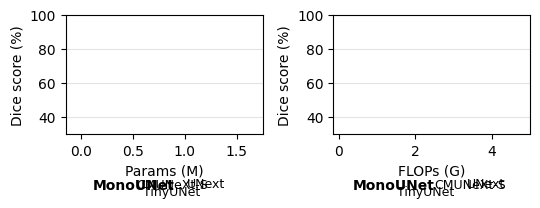

In [117]:
train_dataset_id = 73
test_dataset_id = 70
fold = 0

train_dataset = get_dataset_name(nnUNet_raw, train_dataset_id)
test_dataset = get_dataset_name(nnUNet_raw, test_dataset_id)

plt.figure(figsize=(5.5, 2.5))

markers = ['o', 's', '^', 'D', 'v', 'X', '^', '<', '>', 'p', 'h', 'H', '8', '1']

for model_idx, model in enumerate(models):
    print(f"model: {model}")
    image_wise_results_path = f"models/{model}/{train_dataset}/fold_{fold}/test/results_{test_dataset}.csv"
    model_analysis_path = f"models/{model}/{train_dataset}/model_analysis.json"
    with open(model_analysis_path, 'r') as f:
        model_analysis = json.load(f)
    params = model_analysis['parameters']['total_millions']
    flops = model_analysis['flops']['giga']
    print(f"params: {params}")
    print(f"flops: {flops}")
    
    if not os.path.exists(image_wise_results_path):
        print(f"Skipping {model} fold {fold} - missing {image_wise_results_path}")
        continue
    
    df = pd.read_csv(image_wise_results_path)
    df = df[~df['image_id'].isin(ignore_ids)]
    score = df[metric].values.mean().round(2)
    
    model_display_name = model.replace("MonoUNetE123V2GatedDA", "MonoUNet")
    model_display_name = model_display_name.replace("MonoUNetE123V2GatedV2DA", "MonoUNet")
    model_display_name = model_display_name.replace("UNextDA", "UNext")
    model_display_name = model_display_name.replace("Med_NCA", "Med-NCA")
    model_display_name = model_display_name.replace("Med-NCADA", "Med-NCA")
    model_display_name = model_display_name.replace("CMUNeXt-SDA", "CMUNeXt-S")
    model_display_name = model_display_name.replace("TinyUNetDA", "TinyUNet")
    
    for i, item in enumerate([params, flops]):
        if item == flops and model == "Med_NCA":
            continue
        plt.subplot(1, 2, i+1)
        plt.scatter([item], [score], 
                    color=colors[model_idx], edgecolor='k', s=80 if model_display_name == "MonoUNet" else 60, alpha=0.7, marker=markers[model_idx])
                    
        # Use a proportionate horizontal offset based on x-axis range for each subplot
        ax = plt.gca()
        x_limits = ax.get_xlim()
        x_range = x_limits[1] - x_limits[0]
        offset = x_range * 0.06  # 4% of axis range

        if model_display_name == "MonoUNet":
            plt.text(item + offset, score, model_display_name, fontsize=10, ha='left', va='center', fontweight='bold')
        elif model_display_name == "Med-NCA":
            plt.annotate(model_display_name, (item, score), xytext=(-10, -10), textcoords='offset points', fontsize=10, ha='left', va='top')
        elif model_display_name == "UNext":
            plt.text(item - 8 * offset, score, model_display_name, fontsize=9, ha='right', va='center')
        elif model_display_name == "TinyUNet":
            if item == flops:
                plt.text(item - 1 * offset, score, model_display_name, fontsize=9, ha='right', va='top')
            else:
                plt.text(item + offset, score, model_display_name, fontsize=9, ha='left', va='top')
        else:
            plt.text(item + offset, score, model_display_name, fontsize=9, ha='left', va='center')
        
        plt.grid(True, axis='y', alpha=0.35)
        plt.ylabel('Dice score (%)')
        plt.ylim(30, 100)
        if item == params:
            plt.xlim(-0.15, 1.75)
        if item == flops:
            plt.xlim(-0.15, 5)

        if item == params:
            plt.xlabel('Params (M)')
        else:
            plt.xlabel('FLOPs (G)')
            plt.ylabel('Dice score (%)')

# plt.suptitle(f'{dataset_id2abbr[train_dataset_id]} → {dataset_id2abbr[test_dataset_id]}')
plt.tight_layout()
# plt.savefig(f'results/quantitative/params_flops_vs_{metric}.svg', dpi=300)
plt.savefig(f'results/quantitative/graphical_abstract_performance_{metric}.svg', dpi=300)
plt.show()

# Bland-Altman plots


In [118]:
import pingouin as pg
from matplotlib.ticker import MultipleLocator
from scipy.stats import linregress

# Configuration - modify these to select what to visualize
def compute_icc2k(case_prefixes, pred, gt):
    icc_df = pd.DataFrame({
        'subject': np.concatenate([case_prefixes, case_prefixes]),
        'method': ['manual'] * len(case_prefixes) + ['auto'] * len(case_prefixes),
        'value': np.concatenate([gt, pred]),
    })
    icc_result = pg.intraclass_corr(data=icc_df, targets='subject', raters='method', ratings='value')
    icc_row = icc_result.query("Type == 'ICC2k'").iloc[0]
    ci_low, ci_high = icc_row['CI95']
    return icc_row['ICC'], ci_low, ci_high


def plot_bland_altman(ax, case_prefixes, pred, gt, label, fit_line=False):
    pred = np.array(pred)
    gt = np.array(gt)
    case_prefixes = np.array(case_prefixes)
    valid = (~np.isnan(gt)) & (~np.isnan(pred)) & (gt != 0)
    pred = pred[valid]
    gt = gt[valid]
    case_prefixes = case_prefixes[valid]

    mean = np.mean([pred, gt], axis=0)
    diff = gt - pred
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)

    diff_pct = (gt - pred) / gt * 100
    mean_diff_pct = np.mean(diff_pct)
    std_diff_pct = np.std(diff_pct, ddof=1)

    upper_loa = mean_diff + 1.96 * std_diff
    lower_loa = mean_diff - 1.96 * std_diff
    upper_loa_pct = mean_diff_pct + 1.96 * std_diff_pct
    lower_loa_pct = mean_diff_pct - 1.96 * std_diff_pct

    units = 'mm' if 'thickness' in label else 'a.u.'
    ax.scatter(mean, diff_pct, alpha=0.6, s=10)
    ax.axhline(y=mean_diff_pct, color='r', label=f'Mean: {mean_diff_pct:.2f}% ({mean_diff:.3f} {units})')
    ax.axhline(y=upper_loa_pct, color='g', linestyle='dotted', label=f'95% Upper LOA: {upper_loa_pct:.2f}% ({upper_loa:.3f} {units})')
    ax.axhline(y=lower_loa_pct, color='g', linestyle='dotted', label=f'95% Lower LOA: {lower_loa_pct:.2f}% ({lower_loa:.3f} {units})')
    if fit_line and len(mean) > 1:
        fit = linregress(mean, diff_pct)
        fit_x = np.linspace(mean.min(), mean.max(), 100)
        fit_y = fit.slope * fit_x + fit.intercept
        ax.plot(
            fit_x,
            fit_y,
            color='k',
            linestyle='--',
            label=f'y={fit[0]:.2f}x{fit[1]:+.2f}, p={fit.pvalue:.3f}, R²={fit.rvalue ** 2:.3f}'
        )
    ax.set_xlabel(f'Mean of Manual and MonoUNet {label.title()} ({units})')
    ax.set_ylabel('Manual - MonoUNet (%)')
    ax.set_title(f'Average cartilage {label.lower()}')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-17, 17)
    ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.legend(loc='lower center', ncol=1, bbox_to_anchor=(0.5, -0.75))

Saved Bland-Altman plot to models/MonoUNetE123V2GatedDA/Dataset073_GE_LE/cartilage_outcomes_bland_altman_Dataset070_Clarius_L15.svg


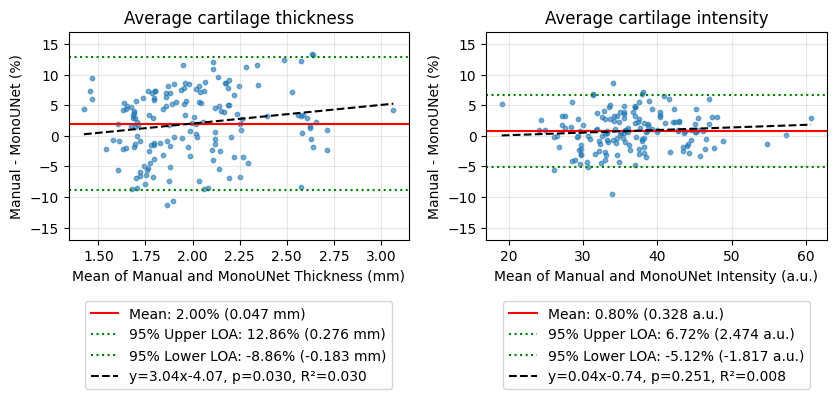

Average cartilage thickness ICC(2,k): 0.960 [0.930, 0.970]
Average cartilage intensity ICC(2,k): 0.992 [0.990, 0.990]


In [119]:
train_dataset_id = 73
test_dataset_id = 70
model = "MonoUNetE123V2GatedDA"
fit_line = True
fold = 0

train_dataset = get_dataset_name(nnUNet_raw, train_dataset_id)
test_dataset = get_dataset_name(nnUNet_raw, test_dataset_id)

fold_outcomes = []
if test_dataset == train_dataset:
    outcomes_csv_path = f"models/{model}/{train_dataset}/cartilage_outcomes_{test_dataset}.csv"
    if os.path.exists(outcomes_csv_path):
        fold_df = pd.read_csv(outcomes_csv_path)
        fold_df = fold_df[~fold_df['image_id'].isin(ignore_ids)].copy()
        fold_outcomes.append(fold_df)
else:
    for current_fold in range(3):
        outcomes_csv_path = f"models/{model}/{train_dataset}/fold_{current_fold}/test/cartilage_outcomes_{test_dataset}.csv"
        if not os.path.exists(outcomes_csv_path):
            continue
        fold_df = pd.read_csv(outcomes_csv_path)
        fold_df = fold_df[~fold_df['image_id'].isin(ignore_ids)].copy()
        fold_outcomes.append(fold_df)
        if fold == 0:
            break

if len(fold_outcomes) == 0:
    raise FileNotFoundError(f"No outcomes CSVs found for {model}, {train_dataset} -> {test_dataset}")

outcomes_df = pd.concat(fold_outcomes, ignore_index=True)
outcomes_df = outcomes_df.groupby('image_id', as_index=False)[['gt_thickness', 'pred_thickness', 'gt_echo_intensity', 'pred_echo_intensity']].mean()
outcomes_df['subject_id'] = outcomes_df['image_id'].map(get_subject_id)
outcomes_df['case_label'] = outcomes_df['image_id'].map(get_case_label)
outcomes_df['case_prefix'] = outcomes_df['image_id'].map(get_case_prefix)

subject_ids = separate_subjects(outcomes_df['image_id'].tolist())
case_df = build_case_df(outcomes_df, subject_ids)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 6))
plot_bland_altman(axes[0], case_df['case_prefix'].values, case_df['pred_thickness'].values, case_df['gt_thickness'].values, 'thickness', fit_line=fit_line)
plot_bland_altman(axes[1], case_df['case_prefix'].values, case_df['pred_echo_intensity'].values, case_df['gt_echo_intensity'].values, 'intensity', fit_line=fit_line)
plt.tight_layout()
save_path = f"models/{model}/{train_dataset}/cartilage_outcomes_bland_altman_{test_dataset}.svg"
plt.savefig(save_path, dpi=300, format="svg", bbox_inches="tight")
print(f"Saved Bland-Altman plot to {save_path}")
plt.show()

thickness_icc, thickness_icc_low, thickness_icc_high = compute_icc2k(case_df['case_prefix'].values, case_df['pred_thickness'].values, case_df['gt_thickness'].values)
intensity_icc, intensity_icc_low, intensity_icc_high = compute_icc2k(case_df['case_prefix'].values, case_df['pred_echo_intensity'].values, case_df['gt_echo_intensity'].values)

print(f"Average cartilage thickness ICC(2,k): {thickness_icc:.3f} [{thickness_icc_low:.3f}, {thickness_icc_high:.3f}]")
print(f"Average cartilage intensity ICC(2,k): {intensity_icc:.3f} [{intensity_icc_low:.3f}, {intensity_icc_high:.3f}]")


# Qualitative results

Using first 5 available images

Image: Tufts_6m_Jamil___s023_v3_6m_l_140_1_179 | Dataset: Dataset073_GE_LE | Fold: 0
model: UNext
model_display_name: UNext
model: Med_NCA
model_display_name: Med_NCA
model: CMUNeXt-S
model_display_name: CMUNeXt-S
model: TinyUNet
model_display_name: TinyUNet
model: MonoUNetE123V2GatedDA
model_display_name: MonoUNet


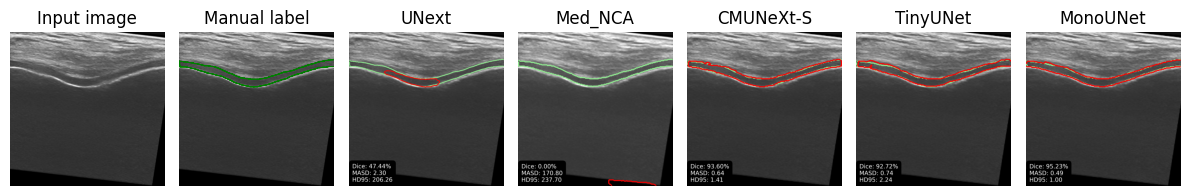


Image: CaseControl_ACL___ACL08_CC21_r1_inj_central_pre_control_3_537 | Dataset: Dataset073_GE_LE | Fold: 0
model: UNext
model_display_name: UNext
model: Med_NCA
model_display_name: Med_NCA
model: CMUNeXt-S
model_display_name: CMUNeXt-S
model: TinyUNet
model_display_name: TinyUNet
model: MonoUNetE123V2GatedDA
model_display_name: MonoUNet


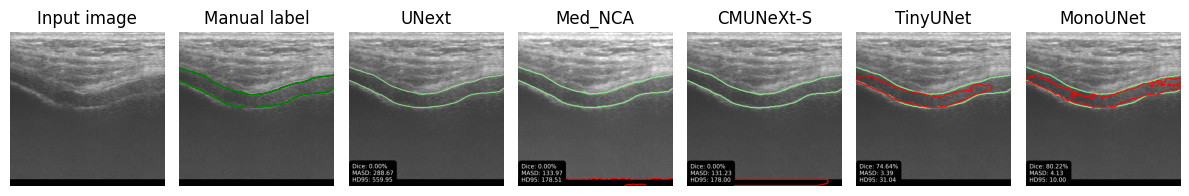


Image: Tufts_3m_Sunny___s031_v2_12w_l_140_3_268 | Dataset: Dataset073_GE_LE | Fold: 0
model: UNext
model_display_name: UNext
model: Med_NCA
model_display_name: Med_NCA
model: CMUNeXt-S
model_display_name: CMUNeXt-S
model: TinyUNet
model_display_name: TinyUNet
model: MonoUNetE123V2GatedDA
model_display_name: MonoUNet


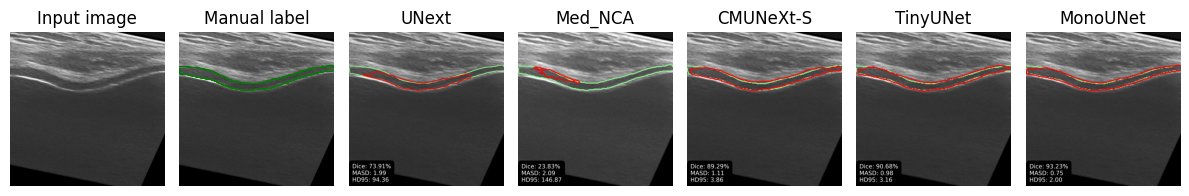


Image: CaseControl_Control___s40_r1_dom_central_pre_control_3_433 | Dataset: Dataset073_GE_LE | Fold: 0
model: UNext
model_display_name: UNext
model: Med_NCA
model_display_name: Med_NCA
model: CMUNeXt-S
model_display_name: CMUNeXt-S
model: TinyUNet
model_display_name: TinyUNet
model: MonoUNetE123V2GatedDA
model_display_name: MonoUNet


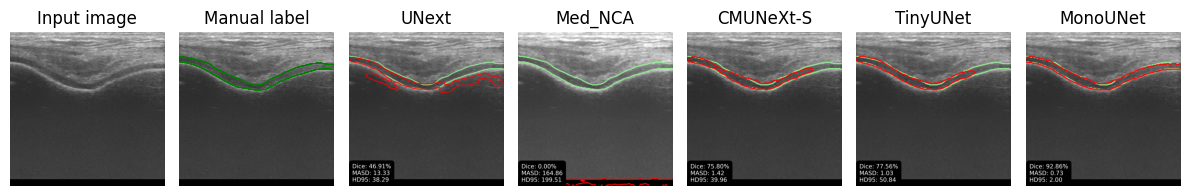


Image: Tufts_3m_Sunny___s023_v2_12w_l_135_3_163 | Dataset: Dataset073_GE_LE | Fold: 0
model: UNext
model_display_name: UNext
model: Med_NCA
model_display_name: Med_NCA
model: CMUNeXt-S
model_display_name: CMUNeXt-S
model: TinyUNet
model_display_name: TinyUNet
model: MonoUNetE123V2GatedDA
model_display_name: MonoUNet


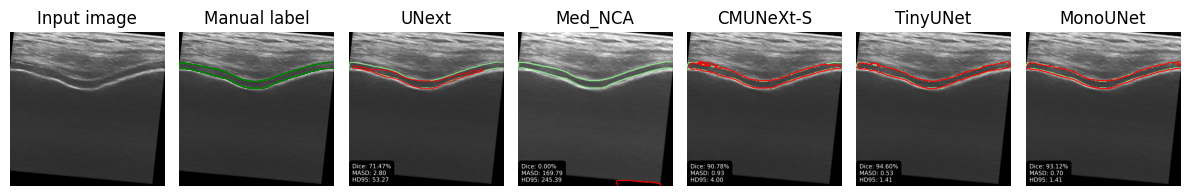


Displayed 5 models for 5 image(s)
Available images: 587 total
To view more images, increase num_images (currently 5)


In [120]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random

# Configuration - modify these to select what to visualize
# train_dataset = "Dataset072_GE_LQP9"
# train_dataset = "Dataset073_GE_LE"
train_dataset = "Dataset070_Clarius_L15"
# test_dataset = "Dataset078_KneeUS_OtherDevices"
test_dataset = "Dataset073_GE_LE"
# test_dataset = "Dataset070_Clarius_L15"
# test_dataset = "Dataset079_KneeUS_Ilker"
# test_dataset = "Dataset072_GE_LQP9"
fold = 0  # Fold number (0-4)
image_name = None  # Specific image name (e.g., "subject_0_clarius_MSK_1_1689.png") or None to use first available
num_images = 5  # Number of images to display (will use first N available images if image_name is None)

# List of models to visualize (using the same list from Cell 2)
models = [
    # "UNextDA",
    "UNext",
    "Med_NCA",
    # "CMUNeXt-SDA",
    "CMUNeXt-S",
    # "TinyUNetDA", 
    "TinyUNet", 
    # "XTinyUNetDA",
    # "XTinyMonoV2GatedEncUNetV1DA",
    "MonoUNetE123V2GatedDA",
    # "MonoUNetE123V2GatedV2DA",
]

# Find available overlay images
overlay_dir_template = "models/{model}/{train_dataset}/fold_{fold}/test/{test_dataset}/overlays"

# Get list of available images from first model that has overlays
available_images = []
for model in models:
    overlay_dir = overlay_dir_template.format(
        model=model, train_dataset=train_dataset, fold=fold, test_dataset=test_dataset
    )
    if os.path.exists(overlay_dir):
        available_images = sorted([f for f in os.listdir(overlay_dir) if f.endswith('.png')])
        break

if test_dataset == "Dataset078_KneeUS_OtherDevices":
    available_images = [i for i in available_images if "cephasonics" not in i]

# Shuffle the images
random.shuffle(available_images)

if not available_images:
    print(f"No overlay images found for {test_dataset} in fold {fold}")
else:
    # Select images to visualize
    if image_name is not None:
        if image_name not in available_images:
            print(f"Warning: {image_name} not found. Using first available: {available_images[0]}")
            images_to_display = [available_images[0]]
        else:
            images_to_display = [image_name]
    else:
        if num_images == -1:
            images_to_display = available_images
            print(f"Using all {len(images_to_display)} available images")
        else:
            images_to_display = available_images[:num_images]
            print(f"Using first {len(images_to_display)} available images")
    
    # Load overlay images for all models and all selected images
    overlay_images = {}  # {image_name: {model: img_array}}
    available_models = []
    
    # First, determine which models are available
    for model in models:
        overlay_path = os.path.join(
            overlay_dir_template.format(
                model=model, train_dataset=train_dataset, fold=fold, test_dataset=test_dataset
            ),
            images_to_display[0]
        )
        if os.path.exists(overlay_path):
            available_models.append(model)
    
    # Load images for all models and all selected images
    for img_name in images_to_display:
        overlay_images[img_name] = {}
        for model in available_models:
            overlay_path = os.path.join(
                overlay_dir_template.format(
                    model=model, train_dataset=train_dataset, fold=fold, test_dataset=test_dataset
                ),
                img_name
            )
            if os.path.exists(overlay_path):
                img = np.array(Image.open(overlay_path))
                overlay_images[img_name][model] = img
            else:
                print(f"Overlay not found for {model}: {overlay_path}")
    
    if not overlay_images:
        print("No overlay images found for any model!")
    else:
        # Display each image in a separate figure with all models
        n_models = len(available_models)
        
        # Load original images from nnUNet dataset
        nnunet_raw = "/home/ultrai/UltrAi/knee_us_segmentation/data/nnUNet_raw"
        original_images = {}
        gt_images = {}
        
        # Determine test split based on dataset name
        if test_dataset in ["Dataset078_KneeUS_OtherDevices", "Dataset079_KneeUS_Ilker"]:
            test_split = "Ts"
        else:
            test_split = "Tr"
        
        dataset_json_path = os.path.join(nnunet_raw, test_dataset, 'dataset.json')
        if os.path.exists(dataset_json_path):
            import json
            with open(dataset_json_path, 'r') as f:
                dataset_info = json.load(f)
            img_ext = dataset_info.get('file_ending', '.png')
            img_dir = os.path.join(nnunet_raw, test_dataset, f'images{test_split}')
            labels_dir = os.path.join(nnunet_raw, test_dataset, f'labels{test_split}')
            
            for img_name in images_to_display:
                img_id = os.path.splitext(img_name)[0]
                img_path = os.path.join(img_dir, f'{img_id}_0000{img_ext}')
                if os.path.exists(img_path):
                    img = np.array(Image.open(img_path))
                    if len(img.shape) == 2:
                        original_images[img_name] = img
                    elif len(img.shape) == 3 and img.shape[2] == 1:
                        original_images[img_name] = img[:, :, 0]
                    else:
                        # Convert to grayscale if RGB
                        original_images[img_name] = np.array(Image.open(img_path).convert('L'))
                else:
                    print(f"Original image not found: {img_path}")
                
                # Load ground truth
                gt_path = os.path.join(labels_dir, f'{img_id}{img_ext}')
                if os.path.exists(gt_path):
                    gt = np.array(Image.open(gt_path))
                    if len(gt.shape) == 2:
                        gt_images[img_name] = gt
                    elif len(gt.shape) == 3 and gt.shape[2] == 1:
                        gt_images[img_name] = gt[:, :, 0]
                    else:
                        # Convert to grayscale if RGB
                        gt_images[img_name] = np.array(Image.open(gt_path).convert('L'))
                else:
                    print(f"Ground truth not found: {gt_path}")
        
        for img_name in images_to_display:
            print(f'\nImage: {os.path.splitext(img_name)[0]} | Dataset: {test_dataset} | Fold: {fold}')
            
            # Create a separate figure for each image (original + GT + all models)
            n_cols = n_models + (1 if img_name in original_images else 0) + (1 if img_name in gt_images else 0)
            fig, axes = plt.subplots(1, n_cols, figsize=(12, 4))
            if n_cols == 1:
                axes = [axes]
            
            col_idx = 0
            
            # Display original image first if available
            if img_name in original_images:
                ax = axes[col_idx]
                # Get target size from overlay image
                if available_models and available_models[0] in overlay_images[img_name]:
                    overlay_shape = overlay_images[img_name][available_models[0]].shape
                    target_size = (overlay_shape[1], overlay_shape[0])  # (width, height)
                    original_img = Image.fromarray(original_images[img_name])
                    original_img = original_img.resize(target_size, Image.Resampling.LANCZOS)
                    original_img = np.array(original_img)
                else:
                    original_img = original_images[img_name]
                ax.imshow(original_img, cmap='gray')
                ax.set_title('Input image') #, fontsize=14)
                ax.axis('off')
                col_idx += 1
            
            # Display ground truth if available
            if img_name in gt_images:
                ax = axes[col_idx]
                # Get target size from overlay image
                if available_models and available_models[0] in overlay_images[img_name]:
                    overlay_shape = overlay_images[img_name][available_models[0]].shape
                    target_size = (overlay_shape[1], overlay_shape[0])  # (width, height)
                    gt_img = Image.fromarray(gt_images[img_name])
                    gt_img = gt_img.resize(target_size, Image.Resampling.LANCZOS)
                    gt_img = np.array(gt_img)
                else:
                    gt_img = gt_images[img_name]
                ax.imshow(original_img, cmap='gray')
                ax.contour(gt_img, colors='green', linewidths=0.5)
                ax.set_title('Manual label') #, fontsize=14)
                ax.axis('off')
                col_idx += 1
                
            
            # Display all models for this image
            for model_idx, model in enumerate(available_models):
                print(f"model: {model}")
                model_display_name = model.replace("MonoUNetE123V2GatedDA", "MonoUNet")
                model_display_name = model_display_name.replace("MonoUNetE123V2GatedV2DA", "MonoUNetV2")
                model_display_name = model_display_name.replace("UNextDA", "UNext")
                model_display_name = model_display_name.replace("CMUNeXt-SDA", "CMUNeXt-S")
                model_display_name = model_display_name.replace("TinyUNetDA", "TinyUNet")
                print(f"model_display_name: {model_display_name}")

                ax = axes[col_idx]
                if model in overlay_images[img_name]:
                    img = overlay_images[img_name][model]
                    ax.imshow(img)
                    ax.set_title(model_display_name) #, fontsize=14)
                else:
                    ax.axis('off')
                ax.axis('off')
                col_idx += 1
            
            os.makedirs('results/qualitative', exist_ok=True)
            plt.tight_layout()
            plt.savefig(f'results/qualitative/{img_name}.svg', dpi=300, bbox_inches='tight', pad_inches=0, format='svg')
            plt.show()
        
        print(f"\nDisplayed {len(available_models)} models for {len(images_to_display)} image(s)")
        print(f"Available images: {len(available_images)} total")
        if len(available_images) > len(images_to_display):
            print(f"To view more images, increase num_images (currently {num_images})")
